In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split

from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, Input
from keras.models import Sequential, Model
from keras.optimizers import Adam
from keras.applications import VGG16, ResNet50V2, ResNet152V2

### Відкриваю та роблю датафрейми

In [2]:
X = np.load('data/X.npy')
Y = np.load('data/Y.npy')

num_images, height, width = X.shape
X_2d = X.reshape(num_images, height * width)

X_df = pd.DataFrame(X_2d)

Y_df = pd.DataFrame(Y)

### Показую відсутність дублікатів та інфорацію про датафрейми

In [3]:
print(f'X: \n{X_df.duplicated().sum()}')
X_df.info()
print(f'Y: \n')
Y_df.info()

X: 
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2062 entries, 0 to 2061
Columns: 4096 entries, 0 to 4095
dtypes: float32(4096)
memory usage: 32.2 MB
Y: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2062 entries, 0 to 2061
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       2062 non-null   float64
 1   1       2062 non-null   float64
 2   2       2062 non-null   float64
 3   3       2062 non-null   float64
 4   4       2062 non-null   float64
 5   5       2062 non-null   float64
 6   6       2062 non-null   float64
 7   7       2062 non-null   float64
 8   8       2062 non-null   float64
 9   9       2062 non-null   float64
dtypes: float64(10)
memory usage: 161.2 KB


### Показую що індекси не відповідають значенням класів

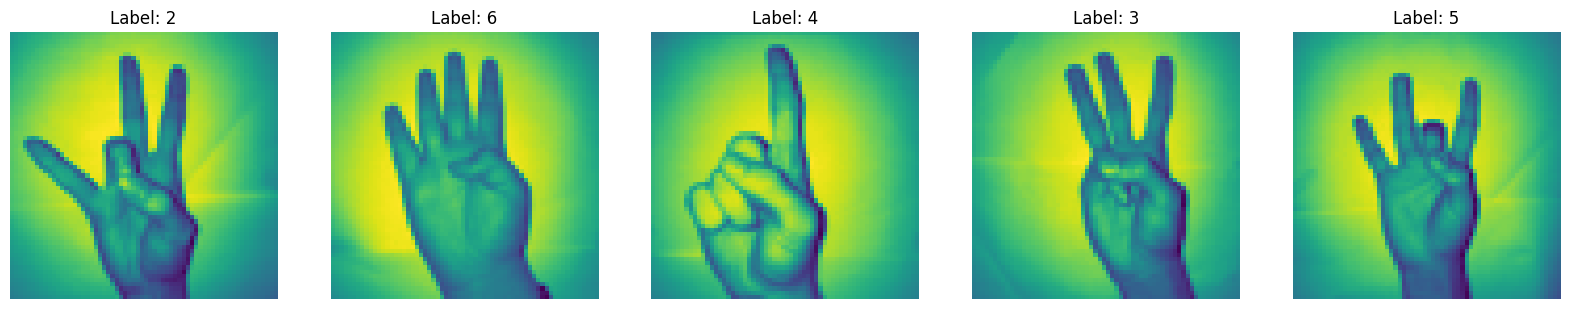

In [4]:

def find_one_index(arr):
    for i, x in enumerate(arr):
        if x == 1:
            return i
            
num_of_examples = 5

fig, ax = plt.subplots(1, num_of_examples, figsize=(20, 5))
for i in range(num_of_examples):
    random_index = np.random.randint(0, len(X))
    random_element = X[random_index]
    random_label = Y[random_index]

    ax[i].imshow(random_element)
    ax[i].axis('off')
    ax[i].set_title(f'Label: {find_one_index(random_label)}')

plt.show()


### Експерементально визначаю який індекс відповідає якому значенню

In [5]:
label_dict = {
    0: 9,
    1: 0,
    2: 7,
    3: 6,
    4: 1,
    5: 8,
    6: 4,
    7: 3,
    8: 2,
    9: 5
}

### Створюю датаферйм із цільовими значеннями

In [6]:
target_df = pd.DataFrame()
target_df['Digit'] = Y_df.apply(lambda row: label_dict[find_one_index(row)], axis=1)
target_df.iloc[::250]

,Digit
0,9
250,0
500,7
750,6
1000,1
1250,4
1500,3
1750,2
2000,5


### Створюю категоріальні значення та таким чином впорядковую датафрейм

In [7]:
dummies = pd.get_dummies(target_df['Digit'])
Y_df_sorted = dummies.astype(float)
Y_df_sorted.head()

,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Правильне відображення цифр

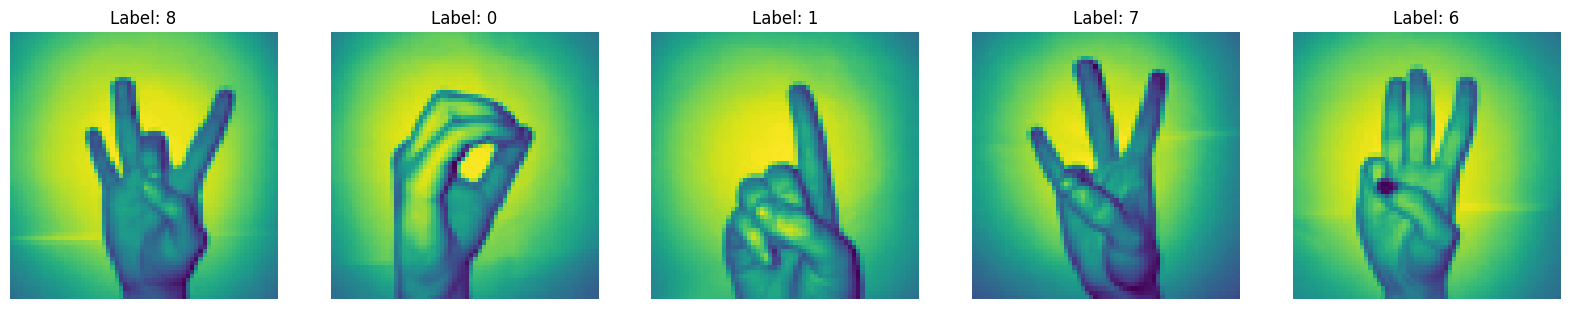

In [8]:
num_of_examples = 5

fig, ax = plt.subplots(1, num_of_examples, figsize=(20, 5))
for i in range(num_of_examples):
    random_index = np.random.randint(0, len(X))
    random_element = X[random_index]
    random_label = target_df.iloc[random_index]['Digit']
    ax[i].imshow(random_element)
    ax[i].axis('off')
    ax[i].set_title(f'Label: {random_label}')
plt.show()


# 4 Module

In [9]:
BATCH_SIZE = 128

image_width, image_height = 64, 64
output_classes = 10

input_shape = (image_width, image_height, 1)

def compile_model(model):
	print('Compiling model...')
	model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

def fit_model(model, X_train, Y_train, epochs=50, verbose=1, batch_size=BATCH_SIZE):
	print('Training model...')
	training_history = model.fit(X_train, Y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1, verbose=verbose)
	return training_history

def evaluate_model(model, X_test, Y_test):
	print('Evaluating model...')
	metrics = model.evaluate(X_test, Y_test, verbose=1)
	print(f'[Results]\n\t- Test loss: {metrics[0]}')
	print(f'\n\t- Test accuracy: {metrics[1]}')
	return metrics

def plot_training_history(history, epochs):
	training_loss = history.history['loss']
	validation_loss = history.history['val_loss']
	training_accuracy = history.history['accuracy']
	validation_accuracy = history.history['val_accuracy']

	epochs_a = range(1, epochs + 1)

	fig, ax = plt.subplots(1, 2, figsize=(15, 5))

	ax[0].plot(epochs_a, training_loss, label='Training loss')
	ax[0].plot(epochs_a, validation_loss, label='Validation loss')
	ax[0].set_title('Training and validation loss for ' + str(epochs) + ' epochs')
	ax[0].set_xlabel('Epochs')
	ax[0].set_ylabel('Loss')
	ax[0].legend()

	ax[1].plot(epochs_a, training_accuracy, label='Training accuracy')
	ax[1].plot(epochs_a, validation_accuracy, label='Validation accuracy')
	ax[1].set_title('Training and validation accuracy for ' + str(epochs) + ' epochs')
	ax[1].set_xlabel('Epochs')
	ax[1].set_ylabel('Accuracy')
	ax[1].legend()


	plt.tight_layout()
	plt.show()

def compile_test_model(model, rgb, msummary=False, epochs=50, verbose=1, batch_size=BATCH_SIZE):
    if rgb == True:
        input_shape = (64, 64, 3)
        X_rgb = np.stack((X,) * 3, axis=-1)
        X_train, X_test, Y_train, Y_test = train_test_split(X_rgb, Y_df_sorted, test_size=0.2, random_state=42)
    else:
        input_shape = (64, 64, 1)
        X_train, X_test, Y_train, Y_test = train_test_split(X, Y_df_sorted, test_size=0.2, random_state=42)

    compile_model(model)
    if msummary == True:
        print(model.summary())
    training_history = fit_model(model, X_train, Y_train, epochs, verbose=verbose, batch_size=batch_size)
    evaluate_model(model, X_test, Y_test)
    plot_training_history(training_history, epochs)


def create_custom_model(base_model_class, chanels, overfit=True ,finneur=512, image_width=64, image_height=64, output_classes=10):
    base_model = base_model_class(weights=None, include_top=False, input_shape=(image_width, image_height, chanels))
    x = base_model.output
    x = Flatten()(x)
    x = Dense(finneur, activation='relu')(x)
    if overfit == True:
        x = Dropout(0.5)(x)    
    predictions = Dense(output_classes, activation='softmax')(x) 
    model = Model(inputs=base_model.input, outputs=predictions)
    
    for layer in base_model.layers:
        layer.trainable = False
    
    return model


---

### Слабка

In [35]:
def myCNNmodel_light():
    model = Sequential() 
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    return model

Compiling model...
Training model...
Evaluating model...
13/13 [==============================] - 0s 3ms/step - loss: 0.5206 - accuracy: 0.8547
[Results]
	- Test loss: 0.5206034779548645

	- Test accuracy: 0.8547216057777405


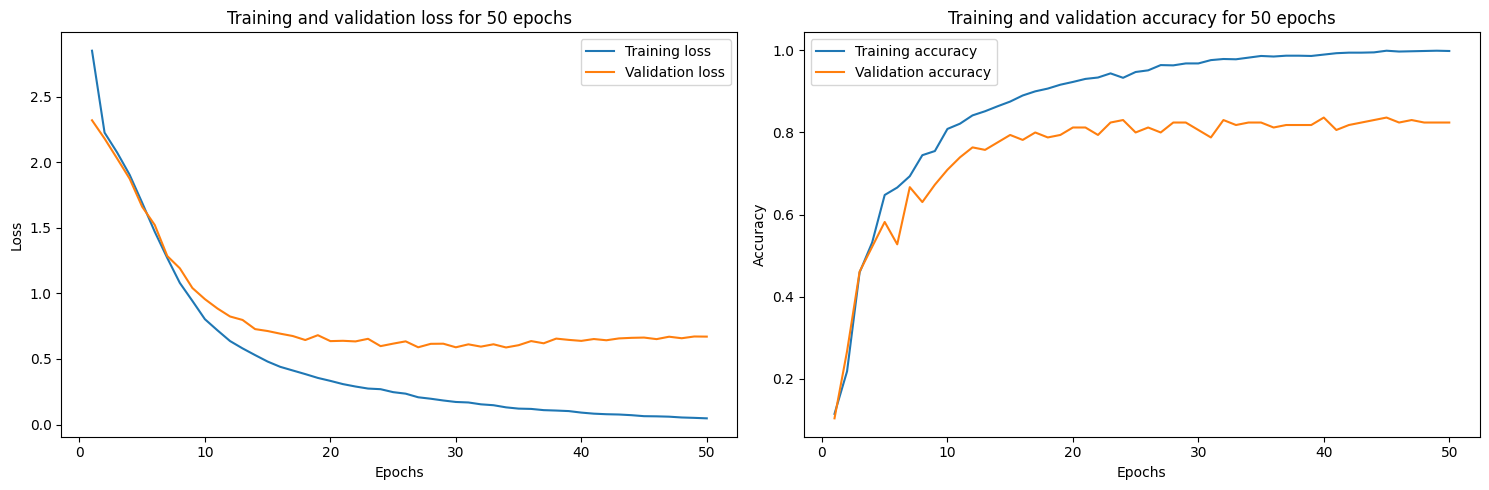

In [36]:
model = myCNNmodel_light()
compile_test_model(model, rgb=False, msummary=False, epochs=50, verbose=0)

---

### Середня

In [37]:
def myCNNmodel_medium():
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))

    return model

Compiling model...
Training model...
Evaluating model...
13/13 [==============================] - 0s 3ms/step - loss: 0.2820 - accuracy: 0.9274
[Results]
	- Test loss: 0.2820321321487427

	- Test accuracy: 0.9273608326911926


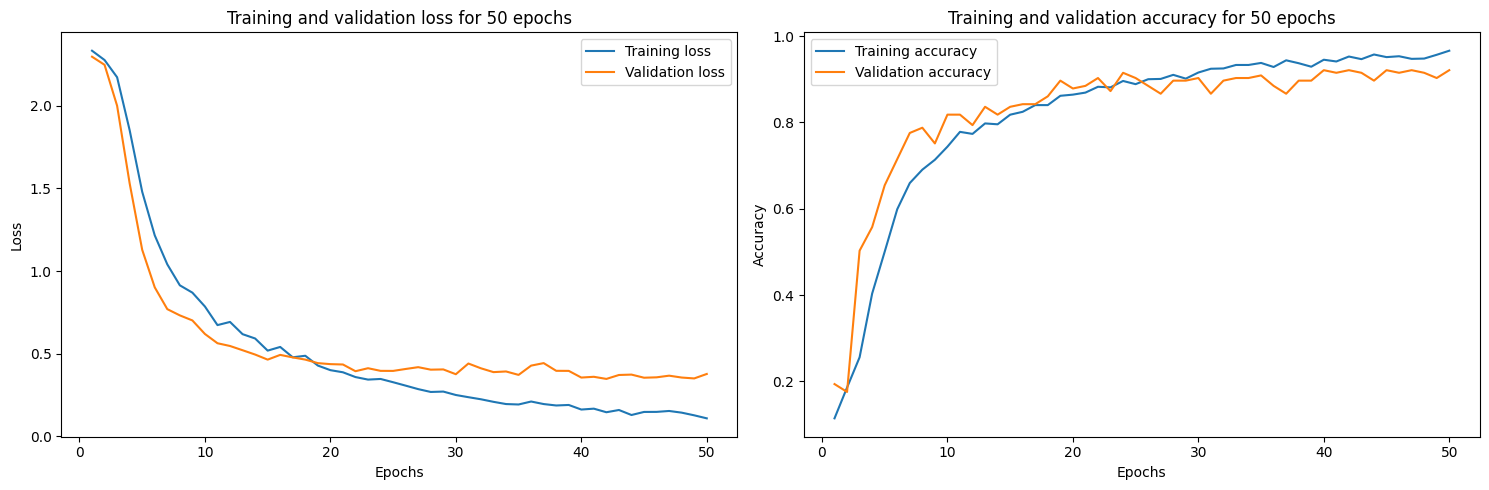

In [38]:
model = myCNNmodel_medium()
compile_test_model(model, rgb=False, msummary=False, epochs=50, verbose=0)

---

### Тяжка модель

In [22]:
def myCNNmodel_hard():
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(256, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(1024, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(output_classes, activation='softmax'))
    return model

Compiling model...
Training model...
Evaluating model...
13/13 [==============================] - 0s 3ms/step - loss: 0.0498 - accuracy: 0.9879
[Results]
	- Test loss: 0.04982094094157219

	- Test accuracy: 0.9878935217857361


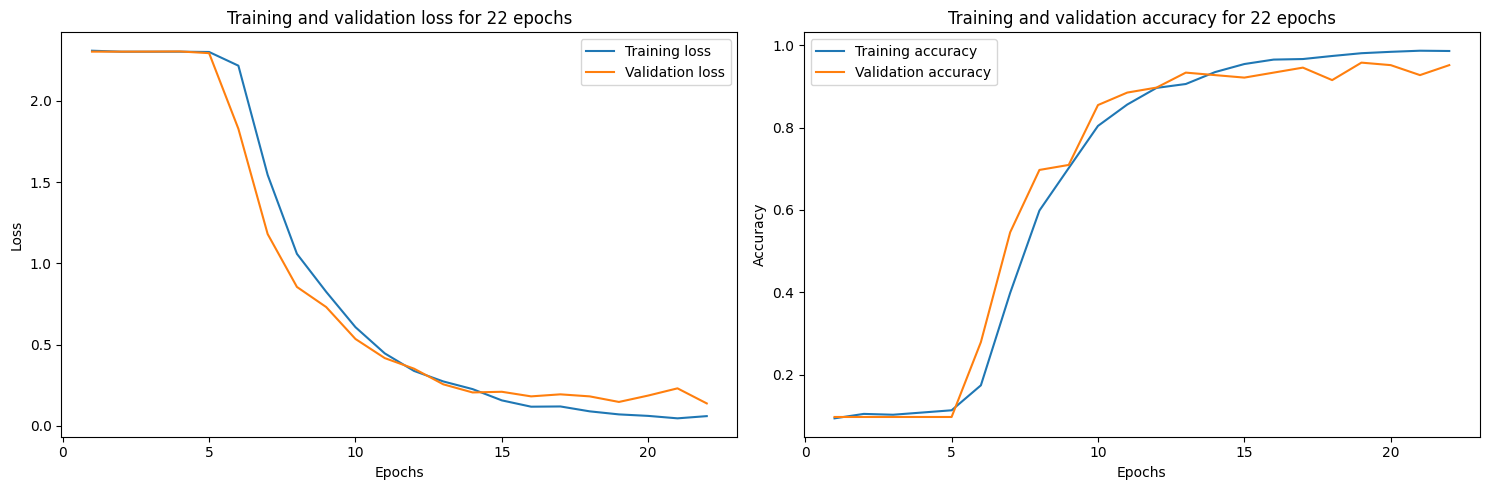

In [36]:
model = myCNNmodel_hard()
compile_test_model(model, rgb=False, msummary=False, epochs=22, verbose=0)

Compiling model...
Training model...
Evaluating model...
13/13 [==============================] - 0s 3ms/step - loss: 0.0885 - accuracy: 0.9758
[Results]
	- Test loss: 0.08853767067193985

	- Test accuracy: 0.9757869839668274


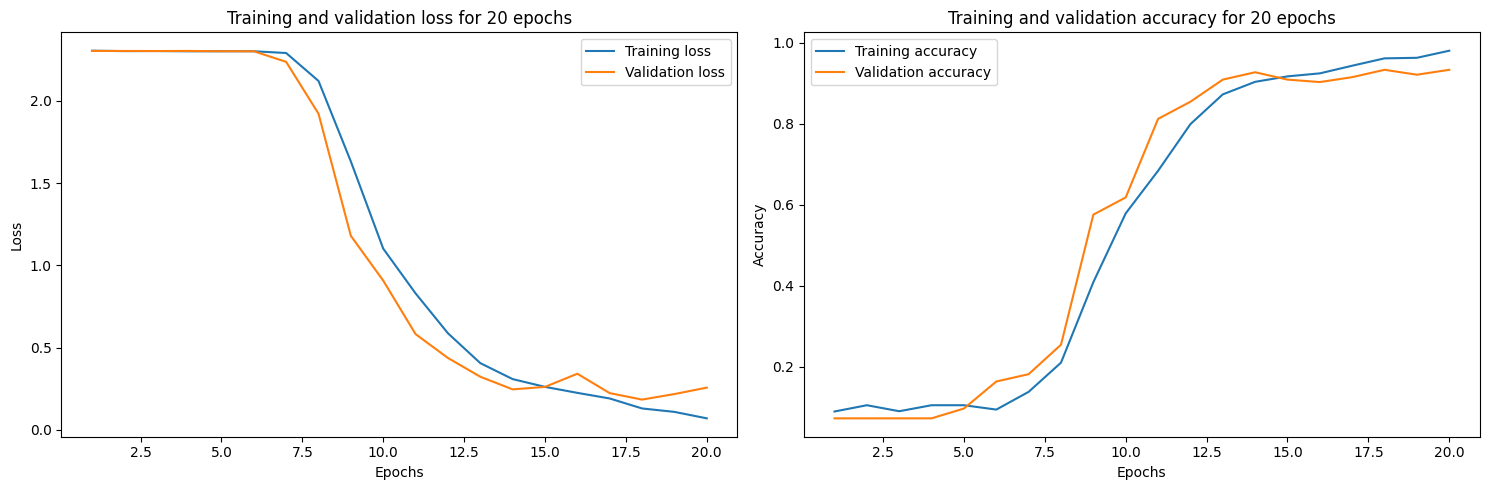

In [34]:
model = myCNNmodel_hard()
compile_test_model(model, rgb=False, msummary=False, epochs=20, verbose=0)

---

# ResNet152V2
87.2 (3)

Compiling model...
Training model...
Evaluating model...
13/13 [==============================] - 0s 19ms/step - loss: 0.4244 - accuracy: 0.8717
[Results]
	- Test loss: 0.4244459271430969

	- Test accuracy: 0.8716707229614258


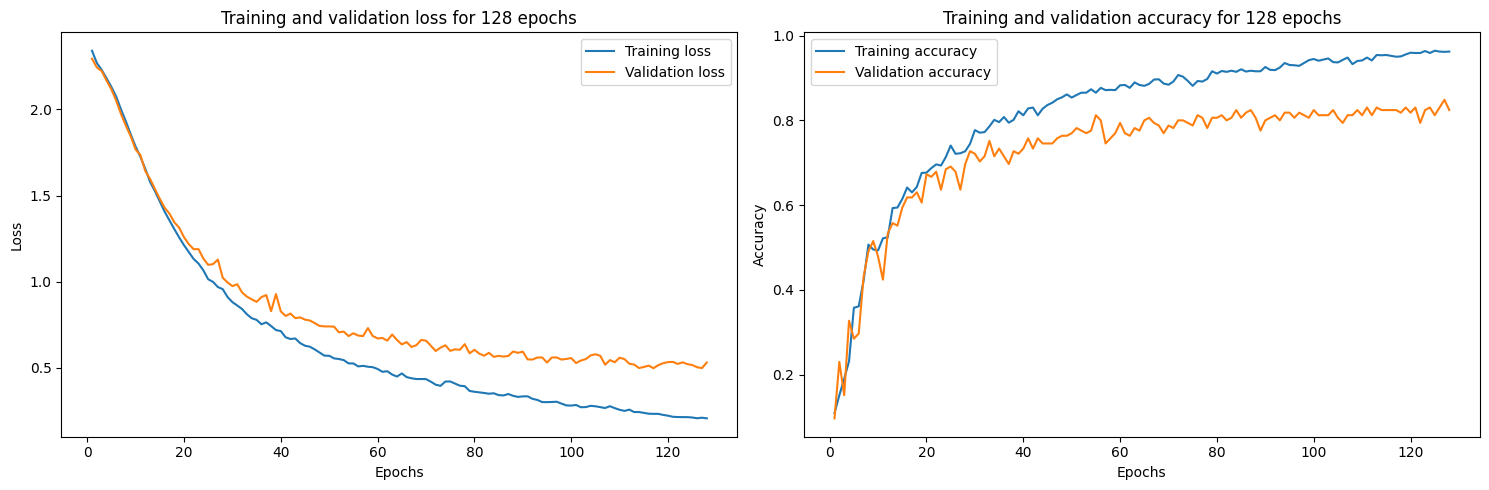

In [13]:
model = create_custom_model(ResNet152V2, 3, overfit=False)
compile_test_model(model, rgb=True ,msummary=False, epochs=128, verbose=0)


---

# ResNet50V2
81.6 (3)

86

Compiling model...
Training model...
Evaluating model...
13/13 [==============================] - 0s 9ms/step - loss: 0.4486 - accuracy: 0.8596
[Results]
	- Test loss: 0.44863268733024597

	- Test accuracy: 0.8595641851425171


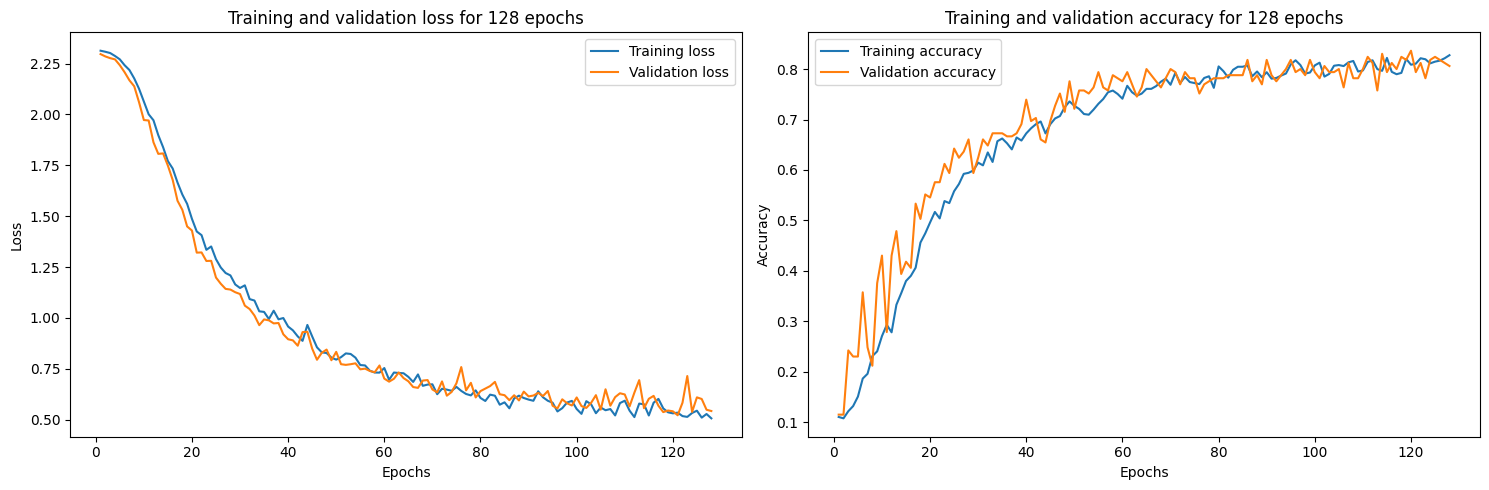

In [56]:
model = create_custom_model(ResNet50V2, 3)
compile_test_model(model, rgb=True, msummary=False, epochs=128, verbose=0)


---

# VGG16
47 (3)

60

Compiling model...
Training model...
Evaluating model...
13/13 [==============================] - 0s 7ms/step - loss: 1.1262 - accuracy: 0.5981
[Results]
	- Test loss: 1.1261872053146362

	- Test accuracy: 0.5980629920959473


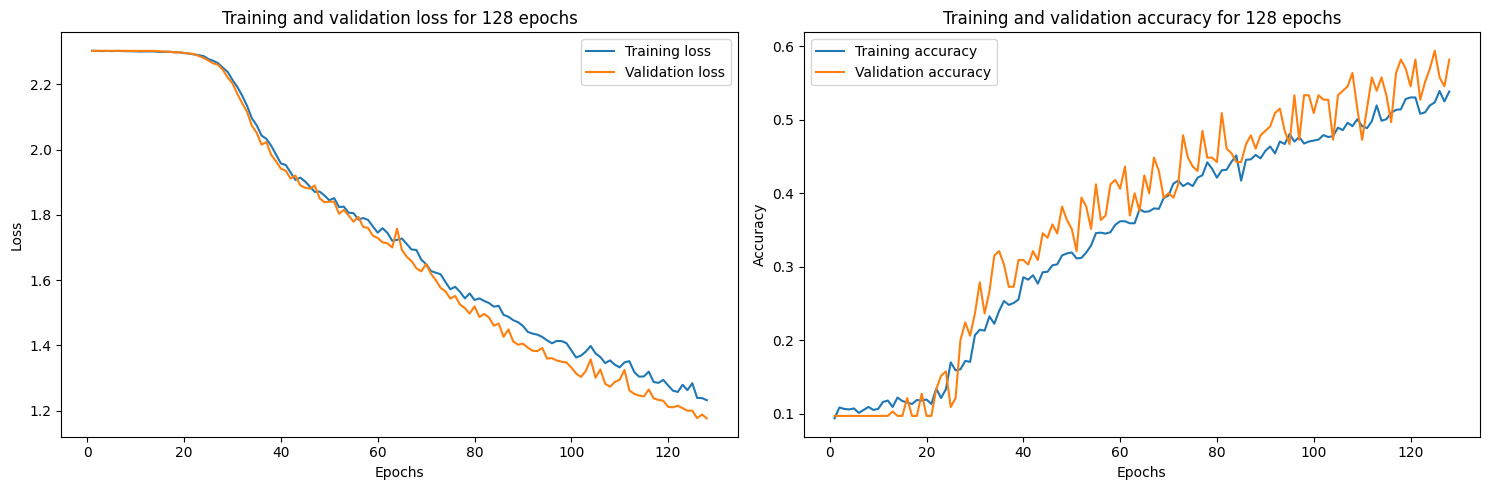

In [57]:
model = create_custom_model(VGG16, 3)
compile_test_model(model, rgb=True, msummary=False, epochs=128, verbose=0, batch_size=128)

---